## 用卷积神经网络训练Cifar10
For this tutorial, we will use the CIFAR10 dataset. It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’, ‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

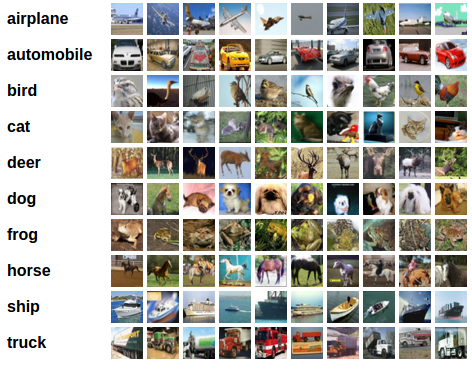

## Training an image classifier
We will do the following steps in order:
- Load and normalize the CIFAR10 training and test datasets using torchvision
- Define a Convolutional Neural Network
- Define a loss function
- Train the network on the training data
- Test the network on the test data

## 1. Load and normalize CIFAR10
Using torchvision, it's extremely easy to load CIFAR10.

In [15]:
import torch
import torchvision
import torchvision.transforms as transforms

The output of torchvision datasets are PILImage images of range [0, 1]. We transform them to Tensors of normalized range [-1, 1].

In [16]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Let us show some of the training images, for fun.

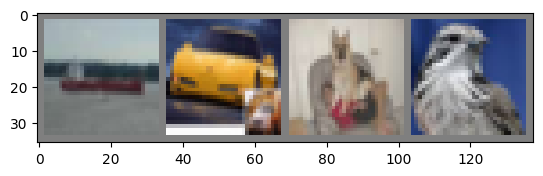

ship  car   dog   bird 


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## 2. Define a Convolutional Neural Network


In [18]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # 4, 6, 28, 28
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
#         x = self.conv1(x)
#         print("output shape of conv1:", x.size())
#         x = F.relu(x)
        
#         x = self.pool(x)
        
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

net = Net().to(device)
print(net)

Using device: cuda:0
Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


## 3. Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

In [19]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## 4. Train the network
This is when things start to get interesting. We simply have to loop over our data iterator, and feed the inputs to the network and optimize.

In [20]:
num_epochs = 10
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    epoch_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        epoch_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    train_losses.append(epoch_loss / len(trainloader))

    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_accuracies.append(100 * correct / total)
    net.train()
    print(f'Epoch {epoch + 1}: train loss = {train_losses[-1]:.3f}, test accuracy = {test_accuracies[-1]:.2f}%')

print('Finished Training')

[1,  2000] loss: 2.174
[1,  4000] loss: 1.829
[1,  6000] loss: 1.685
[1,  8000] loss: 1.596
[1, 10000] loss: 1.542
[1, 12000] loss: 1.499
Epoch 1: train loss = 1.710, test accuracy = 46.78%
[2,  2000] loss: 1.412
[2,  4000] loss: 1.386
[2,  6000] loss: 1.365
[2,  8000] loss: 1.351
[2, 10000] loss: 1.306
[2, 12000] loss: 1.263
Epoch 2: train loss = 1.344, test accuracy = 52.53%
[3,  2000] loss: 1.209
[3,  4000] loss: 1.216
[3,  6000] loss: 1.212
[3,  8000] loss: 1.190
[3, 10000] loss: 1.165
[3, 12000] loss: 1.193
Epoch 3: train loss = 1.199, test accuracy = 58.34%
[4,  2000] loss: 1.099
[4,  4000] loss: 1.109
[4,  6000] loss: 1.108
[4,  8000] loss: 1.101
[4, 10000] loss: 1.102
[4, 12000] loss: 1.103
Epoch 4: train loss = 1.104, test accuracy = 60.65%
[5,  2000] loss: 1.014
[5,  4000] loss: 1.032
[5,  6000] loss: 1.023
[5,  8000] loss: 1.061
[5, 10000] loss: 1.028
[5, 12000] loss: 1.042
Epoch 5: train loss = 1.036, test accuracy = 61.83%
[6,  2000] loss: 0.944
[6,  4000] loss: 0.978
[6, 

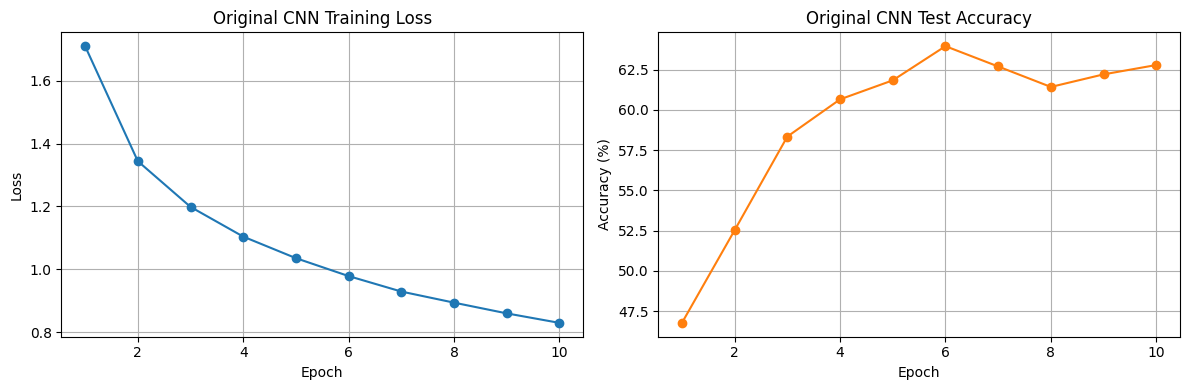

In [21]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Original CNN Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, test_accuracies, marker='o', color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Original CNN Test Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

Let’s quickly save our trained model:

In [22]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

## 5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

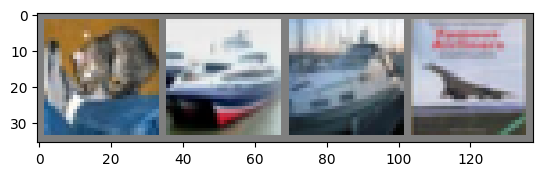

GroundTruth:  cat   ship  ship  plane


In [23]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

Next, let’s load back in our saved model (note: saving and re-loading the model wasn’t necessary here, we only did it to illustrate how to do so):

In [24]:
net = Net().to(device)
net.load_state_dict(torch.load(PATH, map_location=device))
net.eval()

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Okay, now let us see what the neural network thinks these examples above are:

In [25]:
outputs = net(images.to(device))

The outputs are energies for the 10 classes. The higher the energy for a class, the more the network thinks that the image is of the particular class. So, let’s get the index of the highest energy:

In [26]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j].item()]:5s}'
                              for j in range(4)))

Predicted:  cat   plane ship  ship 


The results seem pretty good.

Let us look at how the network performs on the whole dataset.

In [27]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 62 %


That looks way better than chance, which is 10% accuracy (randomly picking a class out of 10 classes). Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did not perform well:

In [28]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label.item()]] += 1
            total_pred[classes[label.item()]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 72.9 %
Accuracy for class: car   is 76.0 %
Accuracy for class: bird  is 34.2 %
Accuracy for class: cat   is 31.9 %
Accuracy for class: deer  is 59.4 %
Accuracy for class: dog   is 68.8 %
Accuracy for class: frog  is 70.8 %
Accuracy for class: horse is 68.6 %
Accuracy for class: ship  is 80.8 %
Accuracy for class: truck is 64.4 %


## ResNet网络结构

ResNetCIFAR(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, af

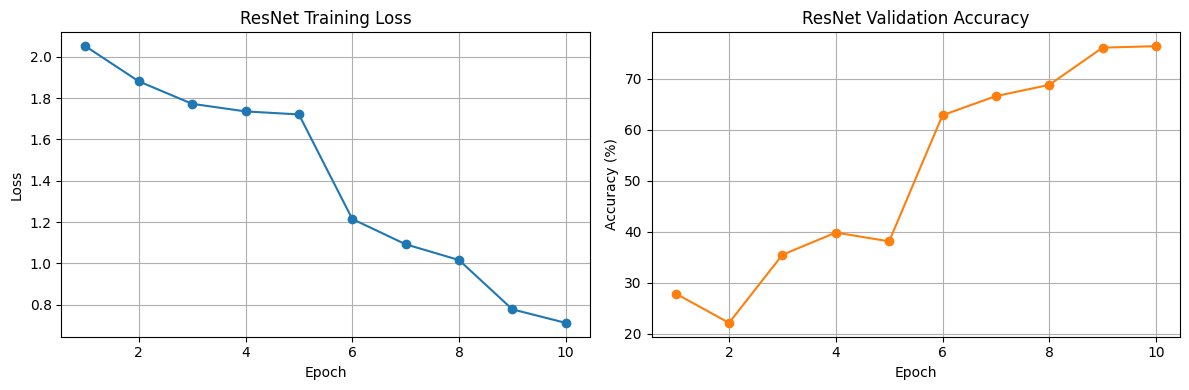

In [29]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class ResNetCIFAR(nn.Module):
    def __init__(self, block=BasicBlock, num_blocks=(2, 2, 2), num_classes=10):
        super().__init__()
        self.in_channels = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for block_stride in strides:
            layers.append(block(self.in_channels, out_channels, block_stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


resnet = ResNetCIFAR().to(device)
print(resnet)

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = optim.SGD(resnet.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
resnet_scheduler = optim.lr_scheduler.MultiStepLR(resnet_optimizer, milestones=[5, 8], gamma=0.1)

num_epochs_resnet = 10
resnet_train_losses = []
resnet_val_accuracies = []

for epoch in range(num_epochs_resnet):
    resnet.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        resnet_optimizer.zero_grad(set_to_none=True)
        outputs = resnet(inputs)
        loss = resnet_criterion(outputs, labels)
        loss.backward()
        resnet_optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[ResNet epoch {epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    resnet_train_losses.append(epoch_loss / len(trainloader))

    correct = 0
    total = 0
    resnet.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = resnet(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    resnet_val_accuracies.append(100 * correct / total)
    resnet_scheduler.step()
    print(f'ResNet epoch {epoch + 1}: train loss = {resnet_train_losses[-1]:.3f}, validation accuracy = {resnet_val_accuracies[-1]:.2f}%')

print('Finished ResNet Training')

resnet_epochs = range(1, num_epochs_resnet + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(resnet_epochs, resnet_train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(resnet_epochs, resnet_val_accuracies, marker='o', color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('ResNet Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## DenseNet网络结构

DenseNetCIFAR(
  (conv1): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (dense1): DenseBlock(
    (block): Sequential(
      (0): DenseLayer(
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(24, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(48, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (1): DenseLayer(
        (bn1): BatchNorm2d(36, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(36, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(48, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (2): DenseLayer(
        (bn1): BatchNorm2d(48, eps=

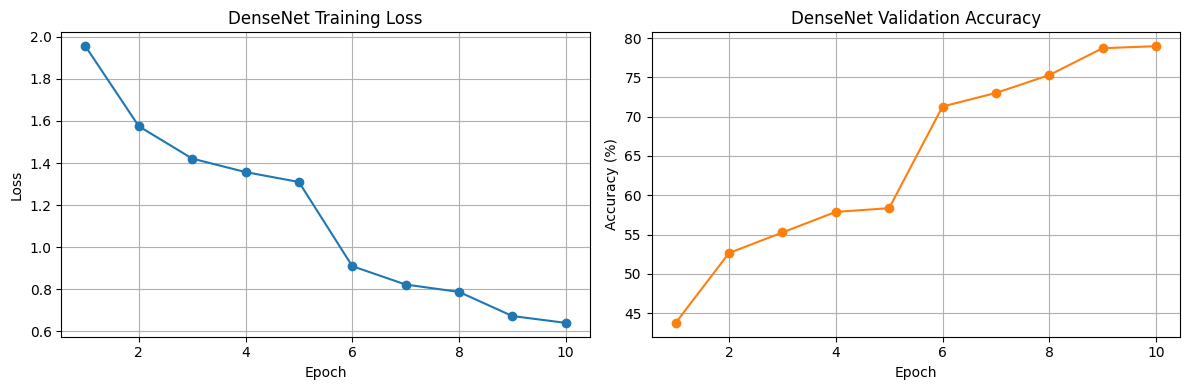

In [30]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4 * growth_rate)
        self.conv2 = nn.Conv2d(4 * growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        out = torch.cat([x, out], dim=1)
        return out


class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super().__init__()
        layers = []
        channels = in_channels
        for _ in range(num_layers):
            layers.append(DenseLayer(channels, growth_rate))
            channels += growth_rate
        self.block = nn.Sequential(*layers)
        self.out_channels = channels

    def forward(self, x):
        return self.block(x)


class Transition(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(F.relu(self.bn(x)))
        x = self.pool(x)
        return x


class DenseNetCIFAR(nn.Module):
    def __init__(self, growth_rate=12, block_layers=(6, 6, 6), compression=0.5, num_classes=10):
        super().__init__()
        channels = 2 * growth_rate
        self.conv1 = nn.Conv2d(3, channels, kernel_size=3, stride=1, padding=1, bias=False)

        self.dense1 = DenseBlock(block_layers[0], channels, growth_rate)
        channels = self.dense1.out_channels
        out_channels = int(channels * compression)
        self.trans1 = Transition(channels, out_channels)
        channels = out_channels

        self.dense2 = DenseBlock(block_layers[1], channels, growth_rate)
        channels = self.dense2.out_channels
        out_channels = int(channels * compression)
        self.trans2 = Transition(channels, out_channels)
        channels = out_channels

        self.dense3 = DenseBlock(block_layers[2], channels, growth_rate)
        channels = self.dense3.out_channels
        self.bn = nn.BatchNorm2d(channels)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels, num_classes)

    def forward(self, x):
        out = self.conv1(x)
        out = self.dense1(out)
        out = self.trans1(out)
        out = self.dense2(out)
        out = self.trans2(out)
        out = self.dense3(out)
        out = F.relu(self.bn(out))
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


densenet = DenseNetCIFAR().to(device)
print(densenet)

densenet_criterion = nn.CrossEntropyLoss()
densenet_optimizer = optim.SGD(densenet.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
densenet_scheduler = optim.lr_scheduler.MultiStepLR(densenet_optimizer, milestones=[5, 8], gamma=0.1)

num_epochs_densenet = 10
densenet_train_losses = []
densenet_val_accuracies = []

for epoch in range(num_epochs_densenet):
    densenet.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        densenet_optimizer.zero_grad(set_to_none=True)
        outputs = densenet(inputs)
        loss = densenet_criterion(outputs, labels)
        loss.backward()
        densenet_optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[DenseNet epoch {epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    densenet_train_losses.append(epoch_loss / len(trainloader))

    correct = 0
    total = 0
    densenet.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = densenet(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    densenet_val_accuracies.append(100 * correct / total)
    densenet_scheduler.step()
    print(f'DenseNet epoch {epoch + 1}: train loss = {densenet_train_losses[-1]:.3f}, validation accuracy = {densenet_val_accuracies[-1]:.2f}%')

print('Finished DenseNet Training')

densenet_epochs = range(1, num_epochs_densenet + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(densenet_epochs, densenet_train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DenseNet Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(densenet_epochs, densenet_val_accuracies, marker='o', color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('DenseNet Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## SE-ResNet网络结构

SEResNetCIFAR(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): SEBasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (se): SEBlock(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=16, out_features=4, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=16, bias=False)
          (3): Sigmoid()
        )
      )
      (shortcut): Sequential()
    )
    (1): SEBasicBlock(
      (conv1): Conv2

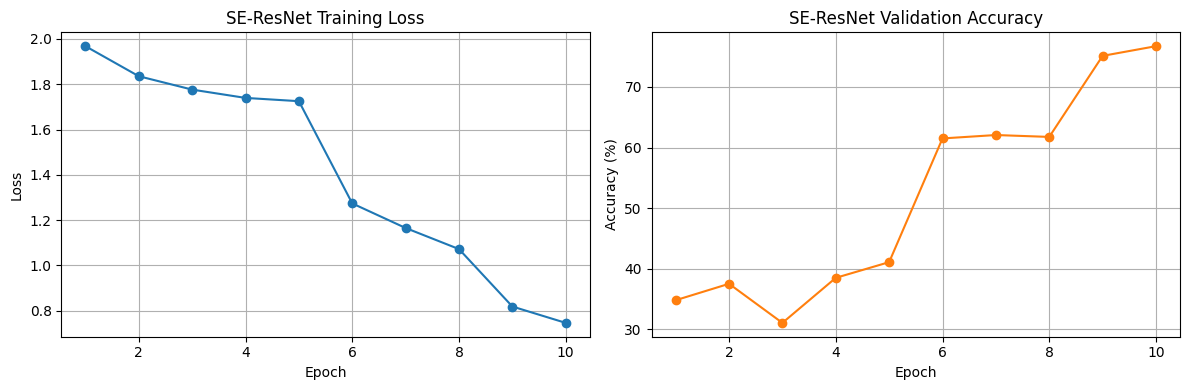

In [37]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden_channels = max(channels // reduction, 4)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden_channels, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_channels, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        weights = self.avg_pool(x).view(batch_size, channels)
        weights = self.fc(weights).view(batch_size, channels, 1, 1)
        return x * weights


class SEBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, reduction=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels, reduction)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class SEResNetCIFAR(nn.Module):
    def __init__(self, block=SEBasicBlock, num_blocks=(2, 2, 2), num_classes=10, reduction=4):
        super().__init__()
        self.in_channels = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1, reduction=reduction)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2, reduction=reduction)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2, reduction=reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride, reduction):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for block_stride in strides:
            layers.append(block(self.in_channels, out_channels, block_stride, reduction))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


seresnet = SEResNetCIFAR().to(device)
print(seresnet)

num_epochs_seresnet = 10
seresnet_criterion = nn.CrossEntropyLoss()
seresnet_optimizer = optim.SGD(seresnet.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
seresnet_scheduler = optim.lr_scheduler.MultiStepLR(seresnet_optimizer, milestones=[5, 8], gamma=0.1)

seresnet_train_losses = []
seresnet_val_accuracies = []

for epoch in range(num_epochs_seresnet):
    seresnet.train()
    running_loss = 0.0
    epoch_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        seresnet_optimizer.zero_grad(set_to_none=True)
        outputs = seresnet(inputs)
        loss = seresnet_criterion(outputs, labels)
        loss.backward()
        seresnet_optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[SE-ResNet epoch {epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    seresnet_train_losses.append(epoch_loss / len(trainloader))

    correct = 0
    total = 0
    seresnet.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = seresnet(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    seresnet_val_accuracies.append(100 * correct / total)
    seresnet_scheduler.step()
    print(f'SE-ResNet epoch {epoch + 1}: train loss = {seresnet_train_losses[-1]:.3f}, validation accuracy = {seresnet_val_accuracies[-1]:.2f}%')

print('Finished SE-ResNet Training')

seresnet_epochs = range(1, num_epochs_seresnet + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(seresnet_epochs, seresnet_train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SE-ResNet Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(seresnet_epochs, seresnet_val_accuracies, marker='o', color='tab:orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('SE-ResNet Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## 四种网络训练曲线对比

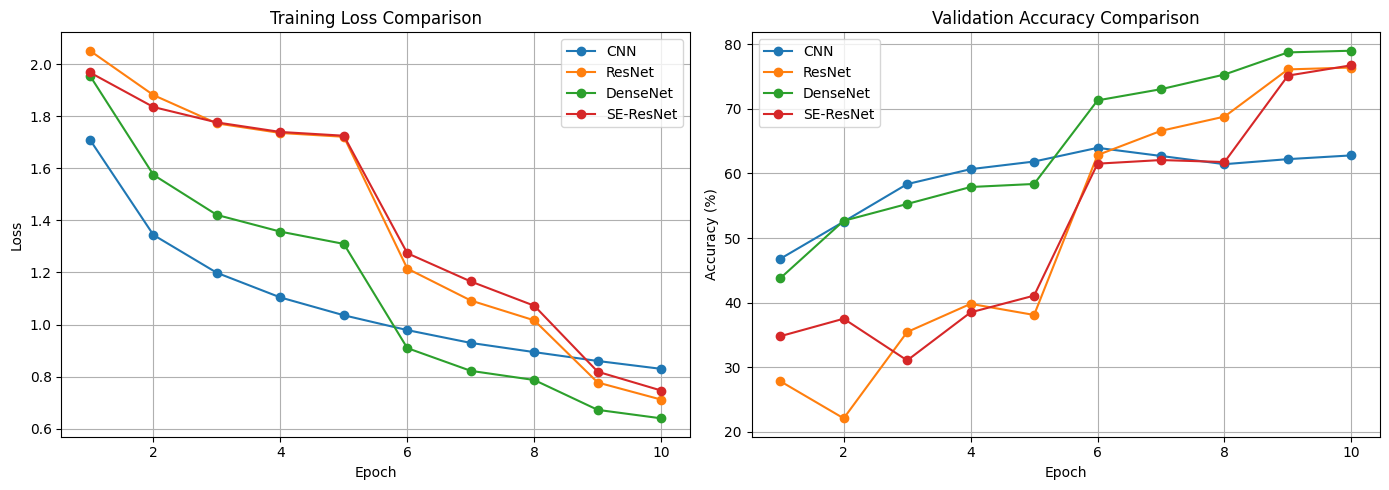

In [38]:
model_curves = {
    'CNN': (train_losses, test_accuracies),
    'ResNet': (resnet_train_losses, resnet_val_accuracies),
    'DenseNet': (densenet_train_losses, densenet_val_accuracies),
    'SE-ResNet': (seresnet_train_losses, seresnet_val_accuracies),
}

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for model_name, (losses, _) in model_curves.items():
    epochs = range(1, len(losses) + 1)
    plt.plot(epochs, losses, marker='o', label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for model_name, (_, accuracies) in model_curves.items():
    epochs = range(1, len(accuracies) + 1)
    plt.plot(epochs, accuracies, marker='o', label=model_name)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Comparison')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()